# Sersic-profile hosts: a transient on a galaxy

A scene `host` is normally either **unresolved** (an integrated `mag`; it rides the source PSF) or a
**uniform surface brightness** (`surface_brightness=True`; the same value in every pixel). A real
transient host is neither: a TDE sits on the cusp of a bulge, a supernova sits an arcsecond out on a
disk, and at the WCC plate scale (16.9 mas/pix) a 1&Prime; galaxy spans ~60 pixels. How much host light
lands *under the aperture* — and therefore the shot noise and the peak pixel — depends on the
profile shape and on where the source sits in it.

`host_prop={"profile": "sersic", ...}` renders the host as an elliptical **Sersic** profile,

$$ I(r) = I_e \exp\left\{-b_n\left[(r/r_e)^{1/n} - 1\right]\right\}, $$

convolves it with the PSF, and feeds that one image to `ImageSimulator.simulate`, `get_snr`,
`get_image_exptime_for_snr`, `get_peak_pixel` and `is_saturated`.

| key | unit | default | meaning |
|---|---|---|---|
| `profile` | str | — | `"sersic"` |
| `r_eff` | arcsec | required | half-light radius along the major axis |
| `n` | – | 1 | Sersic index: 1 = exponential disk, 4 = de Vaucouleurs bulge |
| `ellip` | – | 0 | ellipticity 1 − b/a |
| `pa` | deg | 0 | major-axis position angle, CCW from +x |
| `dx`, `dy` | arcsec | 0 | offset of the host centre from the source |

The normalization reuses the existing flags: `mag` is the **total** host magnitude by default, or
**μ_e** — the surface brightness at `r_eff` in mag/arcsec² — with `surface_brightness=True`.
All parameters are angular; convert physical sizes and absolute magnitudes yourself.

Typical values in r: n = 1–4 (0.5–8 is seen), r_eff ≈ 0.3–1&Prime; for hosts at z ≈ 0.5–1 and
1–10&Prime; for nearby galaxies, μ_e ≈ 20–24 mag/arcsec², total host magnitudes 14–20.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

import wcc_etc
from wcc_etc import Simulation, get_scene
from wcc_etc.psfsim import ImageSimulator

wcc_etc.set_wcc_style()

SENSOR = "zwo:r"  # in-focus r band on the IMX455
TIME = 60.0  # seconds
NPIX = 256  # 256 px = 4.3" on a side


def host_scene(source_mag=21, **host):
    """A mag-21 G5V transient with a G5V Sersic host; host kwargs override the defaults."""
    prop = {"mag": 16, "profile": "sersic", "r_eff": 0.5, "n": 4} | host
    return get_scene("G5V", mag=source_mag, host="G5V", host_prop=prop, background="zodi")

## 1. What the host looks like on the detector

Four hosts of total magnitude 16 with the mag-21 transient (white +) at the grid centre.
Noiseless 60 s images on a log stretch.

[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


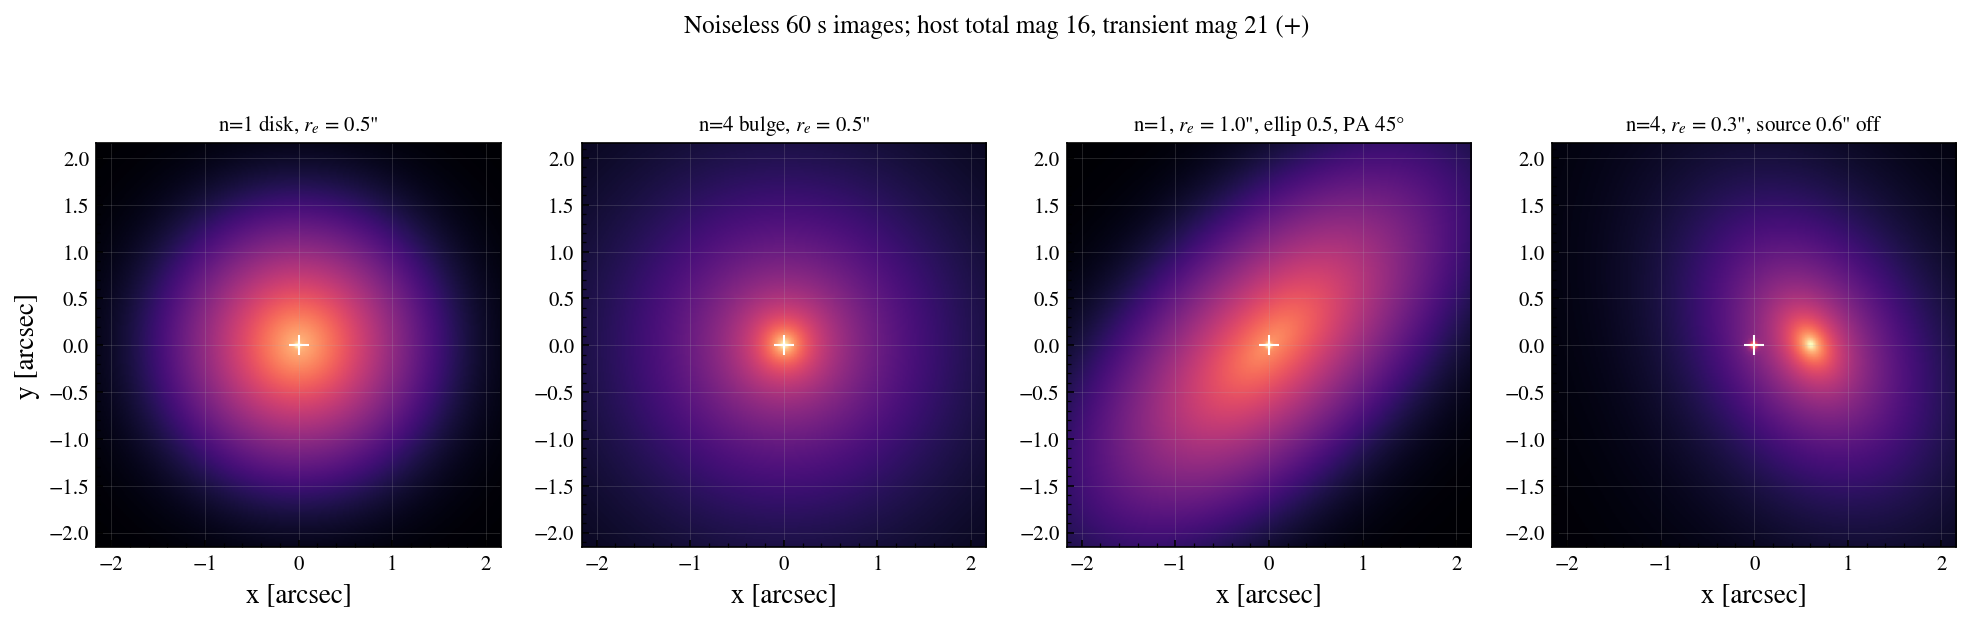

In [2]:
cases = [
    (dict(n=1, r_eff=0.5), 'n=1 disk, $r_e$ = 0.5"'),
    (dict(n=4, r_eff=0.5), 'n=4 bulge, $r_e$ = 0.5"'),
    (dict(n=1, r_eff=1.0, ellip=0.5, pa=45), 'n=1, $r_e$ = 1.0", ellip 0.5, PA 45°'),
    (dict(n=4, r_eff=0.3, ellip=0.3, pa=120, dx=0.6), 'n=4, $r_e$ = 0.3", source 0.6" off'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (kw, title) in zip(axes, cases):
    imsim = ImageSimulator.from_sensorfilter(SENSOR, host_scene(**kw), npix=NPIX)
    img = imsim.simulate(TIME, add_noise=False).image_clean
    half = (NPIX / 2) * imsim.plate_scale_mas / 1000  # arcsec
    ax.imshow(img, origin="lower", norm=LogNorm(vmin=1, vmax=img.max()), cmap="magma",
              extent=[-half, half, -half, half])
    ax.plot(0, 0, "+", color="w", ms=10, mew=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x [arcsec]")
axes[0].set_ylabel("y [arcsec]")
fig.suptitle("Noiseless 60 s images; host total mag 16, transient mag 21 (+)", y=1.02)
plt.show()

One noisy realization of the last case through the ETC's own plotter — the transient is the
faint point 0.6&Prime; to the left of the nucleus.

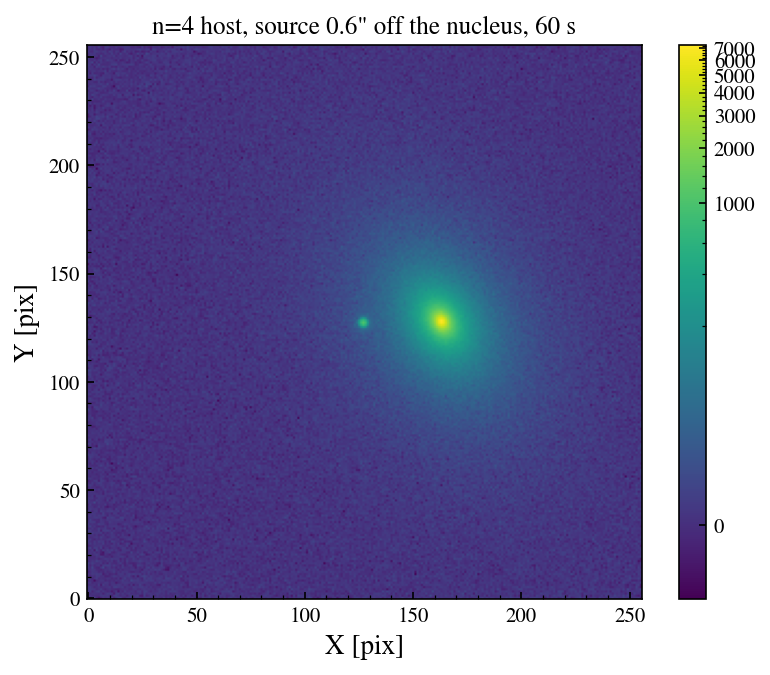

In [3]:
imsim = ImageSimulator.from_sensorfilter(
    SENSOR, host_scene(n=4, r_eff=0.3, ellip=0.3, pa=120, dx=0.6), npix=NPIX
)
imsim.simulate(TIME, seed=1).plot_image(title='n=4 host, source 0.6" off the nucleus, 60 s')
plt.show()

## 2. The two normalizations

* **Total magnitude** (default): a compact host (`r_eff` = 0.1&Prime;, well inside the grid) must carry
  the same count rate as a point source of the same magnitude.
* **μ_e** (`surface_brightness=True`): the pixel at `r_eff` must read the same per-pixel rate as a
  *uniform* surface-brightness host of the same mag/arcsec².

In [4]:
# total-magnitude mode vs a point source of the same magnitude
sim = Simulation.from_sensorfilter(SENSOR, host_scene(r_eff=0.1, n=1))
b = sim._image_render_bundle(sim.default_psf, None, 128, 11)
point = Simulation.from_sensorfilter(SENSOR, get_scene("G5V", mag=16))
point_rate = point._count_rate_components()["source_rate_total"]
host_rate = b["extended_rate_image"].sum()
print(f"point source, mag 16 : {point_rate:9.1f} e-/s")
print(f"Sersic host,  mag 16 : {host_rate:9.1f} e-/s   ratio {host_rate / point_rate:.4f}")

# mu_e mode vs the uniform surface-brightness host
sim_sb = Simulation.from_sensorfilter(SENSOR, host_scene(mag=21, surface_brightness=True, r_eff=0.5, n=1))
b_sb = sim_sb._image_render_bundle(sim_sb.default_psf, None, 128, 11)
uniform = Simulation.from_sensorfilter(
    SENSOR, get_scene("G5V", mag=21, host="G5V", host_prop={"mag": 21, "surface_brightness": True})
)._count_rate_components()["diffuse_rate_per_pix"]
c = 63
r_pix = int(round(0.5 / (b_sb["plate_scale_mas"] / 1000)))
at_re = b_sb["extended_rate_image"][c, c + r_pix]
print(f"uniform SB, mu = 21  : {uniform:9.4f} e-/s/pix")
print(f"Sersic at r_eff      : {at_re:9.4f} e-/s/pix   ratio {at_re / uniform:.3f}")

point source, mag 16 :   17921.5 e-/s
Sersic host,  mag 16 :   17911.7 e-/s   ratio 0.9995


uniform SB, mu = 21  :    0.0510 e-/s/pix
Sersic at r_eff      :    0.0514 e-/s/pix   ratio 1.009


## 3. Nuclear vs offset transient

SNR of the mag-21 transient in 60 s against the host's total magnitude, with the source at the
nucleus (TDE-like) and offset by 0.5&Prime; and 1.5&Prime; (SN-like), on an n=4, r_eff = 0.5&Prime; bulge.
The dashed line is the SNR with no host. Profile parameters are mutable, so
`sim.update(host__mag=..., host__dx=...)` drives the sweep.

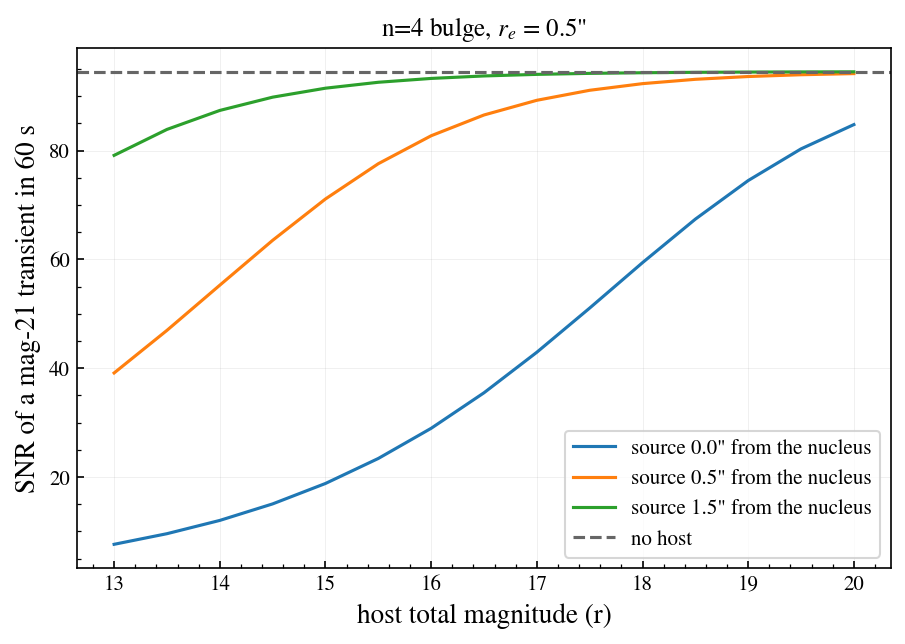

In [5]:
host_mags = np.arange(13, 20.5, 0.5)
hostless = Simulation.from_sensorfilter(SENSOR, get_scene("G5V", mag=21)).get_snr(TIME, warn=False)["snr"]

sim = Simulation.from_sensorfilter(SENSOR, host_scene())
fig, ax = plt.subplots(figsize=(7, 4.5))
for dx in (0.0, 0.5, 1.5):
    snr = []
    for m in host_mags:
        sim.update(host__mag=float(m), host__dx=dx)
        snr.append(sim.get_snr(TIME, warn=False)["snr"])
    ax.plot(host_mags, snr, label=f'source {dx:.1f}" from the nucleus')
ax.axhline(hostless, color="0.4", ls="--", label="no host")
ax.set_xlabel("host total magnitude (r)")
ax.set_ylabel("SNR of a mag-21 transient in 60 s")
ax.set_title('n=4 bulge, $r_e$ = 0.5"')
ax.legend()
plt.show()

## 4. How compact is the host?

At fixed total magnitude, a more compact host puts more light under the nuclear aperture.

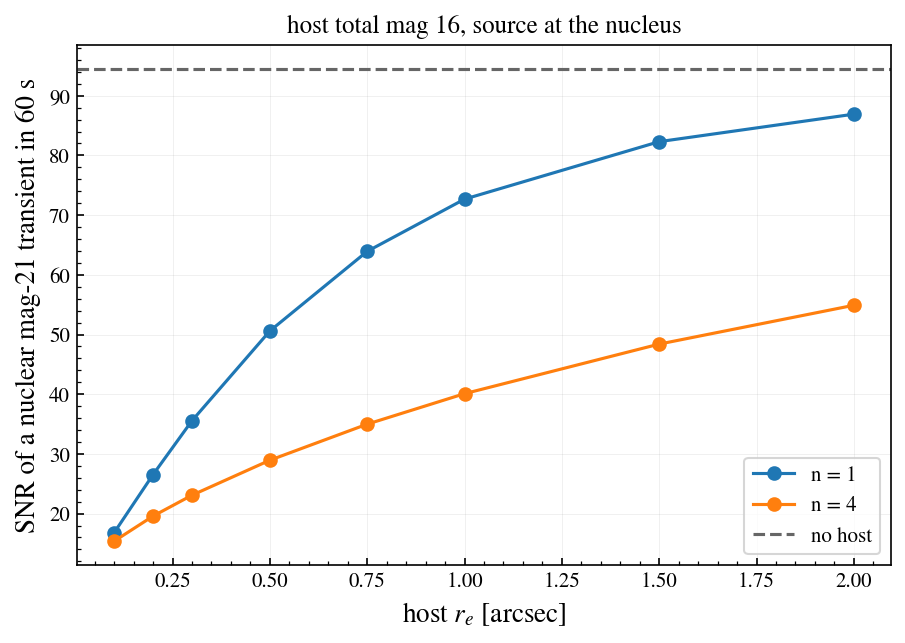

In [6]:
r_effs = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

fig, ax = plt.subplots(figsize=(7, 4.5))
for n in (1, 4):
    sim = Simulation.from_sensorfilter(SENSOR, host_scene(n=n))
    snr = []
    for r in r_effs:
        sim.update(host__r_eff=r)
        snr.append(sim.get_snr(TIME, warn=False)["snr"])
    ax.plot(r_effs, snr, "o-", label=f"n = {n}")
ax.axhline(hostless, color="0.4", ls="--", label="no host")
ax.set_xlabel("host $r_e$ [arcsec]")
ax.set_ylabel("SNR of a nuclear mag-21 transient in 60 s")
ax.set_title("host total mag 16, source at the nucleus")
ax.legend()
plt.show()

## 5. One charge budget

The same host image feeds the saturation and exposure-time APIs: a bright compact bulge saturates
the nucleus long before the transient would, and `get_image_exptime_for_snr` inverts `get_snr`
with the host included.

In [7]:
bright = Simulation.from_sensorfilter(SENSOR, host_scene(mag=12, r_eff=0.3, n=4))
print("peak pixel in 60 s with a mag-12 n=4 host:", bright.get_peak_pixel(TIME, units="e-"))
print("saturated?", bool(bright.is_saturated(TIME)))

sim = Simulation.from_sensorfilter(SENSOR, host_scene())
target = sim.get_snr(TIME, warn=False)["snr"]
t_back = sim.get_image_exptime_for_snr(target, warn=False)["time_s"]
print(f"get_snr(60 s) = {target:.3f}  ->  get_image_exptime_for_snr = {t_back:.2f} s")

peak pixel in 60 s with a mag-12 n=4 host: 225847.1153946794 electron
saturated? True
get_snr(60 s) = 28.943  ->  get_image_exptime_for_snr = 60.00 s


## Summary

* `host_prop={"profile": "sersic", "r_eff": ..., "n": ..., "ellip": ..., "pa": ..., "dx": ..., "dy": ...}`
  — angular parameters; `mag` is the total host magnitude, or μ_e with `surface_brightness=True`.
* One PSF-convolved host image is shared by `simulate`, `get_snr`, `get_image_exptime_for_snr`,
  `get_peak_pixel` and `is_saturated`.
* A mag-16 bulge costs a nuclear mag-21 transient about a factor 3 in SNR; 1.5&Prime; out the loss is a
  few percent. Compact hosts hurt most.
* The deprecated analytic path (`get_snr_airy`) ignores the profile and warns about it.